# Parte A — Truncamento e Arredondamento


## Parte A — Truncamento e arredondamento

Conforme o arquivo da atividade, considere:
- x1 = 3,14159265
- x2 = 98,76543
- x3 = 0,00498765
- n = 0, 1, 2, 3 e 4 casas decimais.

Serão calculados truncamento, arredondamento, erro absoluto, erro relativo e erro percentual,
além da tabela e do gráfico de erro absoluto em escala logarítmica.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def truncar(x, n):
    fator = 10**n
    return math.trunc(x * fator) / fator

def arredondar(x, n):
    # Regra usual: observa o primeiro algarismo descartado.
    fator = 10**n
    return math.floor(x * fator + 0.5) / fator

def calcular_erros(x, x_aprox):
    Ea = abs(x - x_aprox)
    Er = Ea / abs(x)
    Epercentual = 100 * Er
    return Ea, Er, Epercentual

valores = {
    "x1": 3.14159265,
    "x2": 98.76543,
    "x3": 0.00498765
}



In [2]:
resultados = []

for nome, x in valores.items():
    for n in range(5):
        x_trunc = truncar(x, n)
        x_arred = arredondar(x, n)

        Ea_t, Er_t, Ep_t = calcular_erros(x, x_trunc)
        Ea_a, Er_a, Ep_a = calcular_erros(x, x_arred)

        resultados.append([
            nome, x, n,
            x_trunc, x_arred,
            Ea_t, Er_t, Ep_t,
            Ea_a, Er_a, Ep_a
        ])

tabela_A = pd.DataFrame(resultados, columns=[
    "Valor", "Referência", "n",
    "Truncamento", "Arredondamento",
    "Ea Trunc.", "Er Trunc.", "E% Trunc.",
    "Ea Arred.", "Er Arred.", "E% Arred."
])

tabela_A

,Valor,Referência,n,Truncamento,Arredondamento,Ea Trunc.,Er Trunc.,E% Trunc.,Ea Arred.,Er Arred.,E% Arred.
0,x1,3.141593,0,3.0000,3.0000,0.141593,4.507034e-02,4.507034,0.141593,4.507034e-02,4.507034
1,x1,3.141593,1,3.1000,3.1000,0.041593,1.323935e-02,1.323935,0.041593,1.323935e-02,1.323935
2,x1,3.141593,2,3.1400,3.1400,0.001593,5.069562e-04,0.050696,0.001593,5.069562e-04,0.050696
3,x1,3.141593,3,3.1410,3.1420,0.000593,1.886464e-04,0.018865,0.000407,1.296635e-04,0.012966
4,x1,3.141593,4,3.1415,3.1416,0.000093,2.949141e-05,0.002949,0.000007,2.339578e-06,0.000234
5,x2,98.765430,0,98.0000,99.0000,0.765430,7.749979e-03,0.774998,0.234570,2.375021e-03,0.237502
6,x2,98.765430,1,98.7000,98.8000,0.065430,6.624788e-04,0.066248,0.034570,3.500213e-04,0.035002
7,x2,98.765430,2,98.7600,98.7700,0.005430,5.497875e-05,0.005498,0.004570,4.627125e-05,0.004627
8,x2,98.765430,3,98.7650,98.7650,0.000430,4.353750e-06,0.000435,0.000430,4.353750e-06,0.000435
9,x2,98.765430,4,98.7654,98.7654,0.000030,3.037500e-07,0.000030,0.000030,3.037500e-07,0.000030


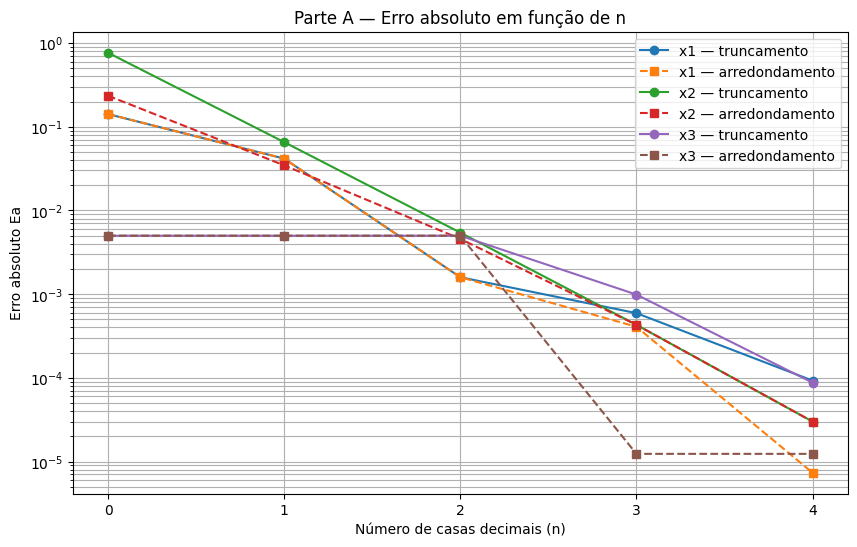

In [3]:
# Gráfico obrigatório: Ea em função de n, em escala logarítmica.

plt.figure(figsize=(10, 6))

for nome in valores:
    dados = tabela_A[tabela_A["Valor"] == nome]

    plt.semilogy(
        dados["n"], dados["Ea Trunc."],
        marker="o", label=f"{nome} — truncamento"
    )

    plt.semilogy(
        dados["n"], dados["Ea Arred."],
        marker="s", linestyle="--",
        label=f"{nome} — arredondamento"
    )

plt.xlabel("Número de casas decimais (n)")
plt.ylabel("Erro absoluto Ea")
plt.title("Parte A — Erro absoluto em função de n")
plt.xticks(range(5))
plt.grid(True, which="both")
plt.legend()
plt.show()


### 5 - Conclusão

Sim. Para aproximações com o mesmo número de casas decimais, o arredondamento produz erro absoluto menor ou igual ao truncamento.

Isso ocorre porque o arredondamento escolhe o múltiplo de $10^{-n}$ mais próximo do valor exato. O truncamento, por outro lado, apenas elimina as casas posteriores, sem verificar qual dos valores representáveis está mais próximo.

Os erros podem ser iguais quando o valor já possui exatamente as casas consideradas ou quando ambos os procedimentos levam à mesma aproximação.

---


# Parte B — Medidas de Pressão Arterial


## Parte B — Medidas de pressão arterial

Dados do arquivo:
121,7; 120,4; 122,1; 119,8; 121,2; 120,9; 122,4; 121,0; 120,2; 121,5.

Serão criadas as séries original, arredondada para inteiro e truncada para inteiro.
Para cada uma serão calculados média, mínimo, máximo, amplitude e desvio-padrão amostral.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pressao = np.array([
    121.7, 120.4, 122.1, 119.8, 121.2,
    120.9, 122.4, 121.0, 120.2, 121.5
])

# Arredondamento para o inteiro mais próximo
pressao_arred = np.floor(pressao + 0.5)

# Truncamento para números inteiros
pressao_trunc = np.trunc(pressao)

media_referencia = pressao.mean()

print("Média de referência =", media_referencia)

Média de referência = 121.12


In [5]:
def estatisticas(serie):
    media = serie.mean()
    minimo = serie.min()
    maximo = serie.max()
    amplitude = maximo - minimo
    desvio = serie.std(ddof=1)

    return media, minimo, maximo, amplitude, desvio

series = {
    "Original": pressao,
    "Arredondado": pressao_arred,
    "Truncado": pressao_trunc
}

linhas = []

for nome, serie in series.items():
    media, minimo, maximo, amplitude, desvio = estatisticas(serie)

    Ea = abs(media_referencia - media)
    Er = Ea / abs(media_referencia)
    Epercentual = 100 * Er

    linhas.append([
        nome, media, minimo, maximo, amplitude, desvio,
        Ea, Er, Epercentual
    ])

tabela_B = pd.DataFrame(linhas, columns=[
    "Série", "Média", "Mínimo", "Máximo", "Amplitude",
    "Desvio-padrão amostral", "Ea da média",
    "Er da média", "E% da média"
])

tabela_B

,Série,Média,Mínimo,Máximo,Amplitude,Desvio-padrão amostral,Ea da média,Er da média,E% da média
0,Original,121.12,119.8,122.4,2.6,0.833733,0.00,0.000000,0.000000
1,Arredondado,121.10,120.0,122.0,2.0,0.875595,0.02,0.000165,0.016513
2,Truncado,120.70,119.0,122.0,3.0,0.948683,0.42,0.003468,0.346764


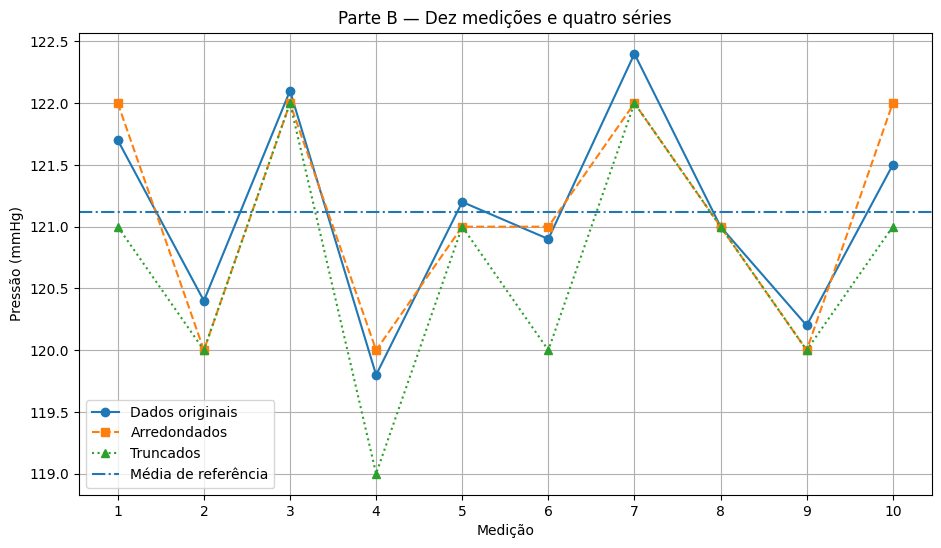

In [6]:
# 1. Gráfico das dez medições mostrando as séries.

x = np.arange(1, 11)

plt.figure(figsize=(11, 6))
plt.plot(x, pressao, marker="o", label="Dados originais")
plt.plot(x, pressao_arred, marker="s", linestyle="--", label="Arredondados")
plt.plot(x, pressao_trunc, marker="^", linestyle=":", label="Truncados")
plt.axhline(media_referencia, linestyle="-.", label="Média de referência")

plt.xlabel("Medição")
plt.ylabel("Pressão (mmHg)")
plt.title("Parte B — Dez medições e quatro séries")
plt.xticks(x)
plt.grid(True)
plt.legend()
plt.show()

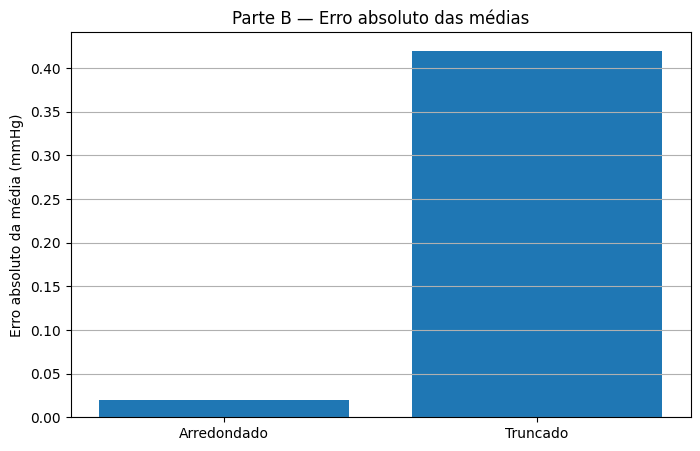

In [7]:
# 2. Gráfico de barras dos erros absolutos das médias.

dados = tabela_B[tabela_B["Série"] != "Original"]

plt.figure(figsize=(8, 5))
plt.bar(dados["Série"], dados["Ea da média"])
plt.ylabel("Erro absoluto da média (mmHg)")
plt.title("Parte B — Erro absoluto das médias")
plt.grid(axis="y")
plt.show()

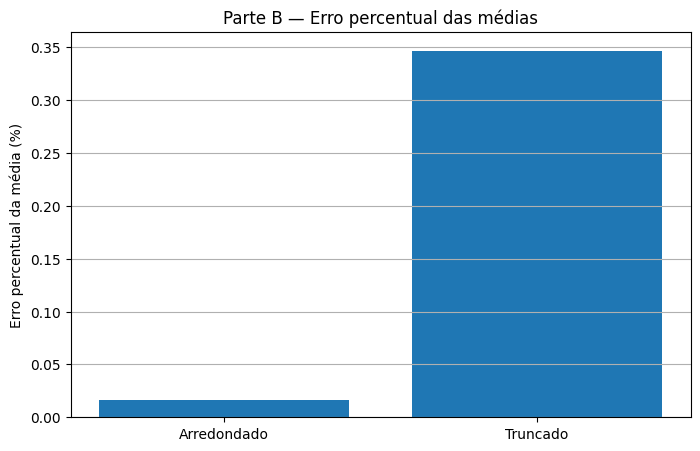

In [8]:
# 3. Gráfico de barras dos erros percentuais das médias.

plt.figure(figsize=(8, 5))
plt.bar(dados["Série"], dados["E% da média"])
plt.ylabel("Erro percentual da média (%)")
plt.title("Parte B — Erro percentual das médias")
plt.grid(axis="y")
plt.show()

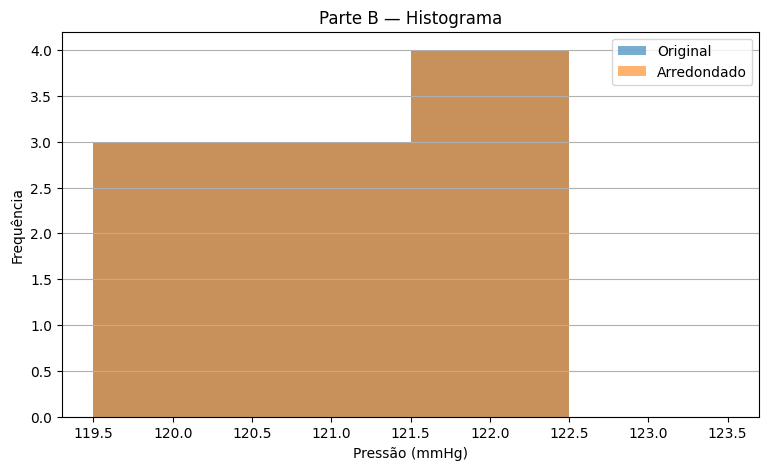

In [9]:
# 4. Histograma dos dados originais e dos dados inteiros arredondados.

bins = np.arange(119.5, 123.6, 1)

plt.figure(figsize=(9, 5))
plt.hist(pressao, bins=bins, alpha=0.6, label="Original")
plt.hist(pressao_arred, bins=bins, alpha=0.6, label="Arredondado")

plt.xlabel("Pressão (mmHg)")
plt.ylabel("Frequência")
plt.title("Parte B — Histograma")
plt.grid(axis="y")
plt.legend()
plt.show()

### Análise solicitada

O arredondamento para valores inteiros mantém a média desta amostra mais próxima do valor original quando comparado ao truncamento.

Porém, ao remover as casas decimais das medições, algumas características dos dados, como a amplitude e o desvio-padrão, também sofrem alterações. Dessa forma, o uso de valores inteiros pode ser adequado para uma análise aproximada, mas provoca perda de parte da precisão presente nos dados originais.

Conforme proposto na atividade, os valores são analisados apenas do ponto de vista numérico, sem qualquer interpretação médica.

---


# Parte C — Vazão em um Tubo de Pequeno Diâmetro


## Parte C — Vazão em um tubo de pequeno diâmetro

Será utilizada a relação de Hagen–Poiseuille:

Q = π r⁴ Δp / (8 μ L)

Dados do arquivo:
- r = 0,80 mm
- L = 0,20 m
- μ = 3,5 × 10⁻³ Pa·s
- Δp = 1200 Pa

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def truncar(x, n):
    fator = 10**n
    return math.trunc(x * fator) / fator

def arredondar(x, n):
    fator = 10**n
    return math.floor(x * fator + 0.5) / fator

def vazao(r, mu, delta_p, L):
    return math.pi * r**4 * delta_p / (8 * mu * L)

def erros(valor_ref, valor_aprox):
    Ea = abs(valor_ref - valor_aprox)
    Er = Ea / abs(valor_ref)
    Epercentual = 100 * Er
    return Ea, Er, Epercentual

r = 0.80e-3
L = 0.20
mu = 3.5e-3
delta_p = 1200.0

Q_ref = vazao(r, mu, delta_p, L)

print(f"Q de referência = {Q_ref:.12e} m³/s")

Q de referência = 2.757420751951e-07 m³/s


### C.1 — Precisão das variáveis

In [11]:
cenarios = []

# Referência
cenarios.append(("Todos os valores fornecidos", r, mu, delta_p))

# r arredondado/truncado para uma casa decimal em mm
r_arred_mm = arredondar(0.80, 1)
r_trunc_mm = truncar(0.80, 1)

cenarios.append(("r arredondado", r_arred_mm * 1e-3, mu, delta_p))
cenarios.append(("r truncado", r_trunc_mm * 1e-3, mu, delta_p))

# mu arredondada/truncada para três casas decimais
mu_arred = arredondar(mu, 3)
mu_trunc = truncar(mu, 3)

cenarios.append(("mu arredondada", r, mu_arred, delta_p))
cenarios.append(("mu truncada", r, mu_trunc, delta_p))

# delta_p arredondado/truncado para centenas de Pa
dp_arred = arredondar(delta_p, -2)
dp_trunc = truncar(delta_p, -2)

# Como a fórmula x*10^n é usada para n inteiro, para centenas usamos:
dp_arred = round(delta_p / 100) * 100
dp_trunc = math.trunc(delta_p / 100) * 100

cenarios.append(("delta_p arredondado", r, mu, dp_arred))
cenarios.append(("delta_p truncado", r, mu, dp_trunc))

# Todas as aproximações simultaneamente
cenarios.append(("Todas arredondadas", r_arred_mm * 1e-3, mu_arred, dp_arred))
cenarios.append(("Todas truncadas", r_trunc_mm * 1e-3, mu_trunc, dp_trunc))

resultados = []

for nome, rr, mm, dp in cenarios:
    Q = vazao(rr, mm, dp, L)
    Ea, Er, Ep = erros(Q_ref, Q)

    resultados.append([
        nome, rr, mm, dp, Q, Ea, Er, Ep
    ])

tabela_C = pd.DataFrame(resultados, columns=[
    "Cenário", "r (m)", "μ (Pa·s)", "Δp (Pa)",
    "Q (m³/s)", "Ea", "Er", "E%"
])

tabela_C

,Cenário,r (m),μ (Pa·s),Δp (Pa),Q (m³/s),Ea,Er,E%
0,Todos os valores fornecidos,0.0008,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
1,r arredondado,0.0008,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
2,r truncado,0.0008,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
3,mu arredondada,0.0008,0.0040,1200.0,2.412743e-07,3.446776e-08,0.125000,12.500000
4,mu truncada,0.0008,0.0030,1200.0,3.216991e-07,4.595701e-08,0.166667,16.666667
5,delta_p arredondado,0.0008,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
6,delta_p truncado,0.0008,0.0035,1200.0,2.757421e-07,0.000000e+00,0.000000,0.000000
7,Todas arredondadas,0.0008,0.0040,1200.0,2.412743e-07,3.446776e-08,0.125000,12.500000
8,Todas truncadas,0.0008,0.0030,1200.0,3.216991e-07,4.595701e-08,0.166667,16.666667


### C.2 — Sensibilidade ao raio

In [12]:
raios_mm = np.round(np.arange(0.70, 0.90 + 0.001, 0.01), 2)

Q_referencia = np.array([
    vazao(rr * 1e-3, mu, delta_p, L)
    for rr in raios_mm
])

raios_arred = np.array([
    arredondar(float(rr), 1)
    for rr in raios_mm
])

raios_trunc = np.array([
    truncar(float(rr), 1)
    for rr in raios_mm
])

Q_arred = np.array([
    vazao(rr * 1e-3, mu, delta_p, L)
    for rr in raios_arred
])

Q_trunc = np.array([
    vazao(rr * 1e-3, mu, delta_p, L)
    for rr in raios_trunc
])

Ea_arred = np.abs(Q_referencia - Q_arred)
Ea_trunc = np.abs(Q_referencia - Q_trunc)

Er_arred = Ea_arred / np.abs(Q_referencia)
Er_trunc = Ea_trunc / np.abs(Q_referencia)

Ep_arred = 100 * Er_arred
Ep_trunc = 100 * Er_trunc

tabela_sensibilidade = pd.DataFrame({
    "r (mm)": raios_mm,
    "r arred. (mm)": raios_arred,
    "r trunc. (mm)": raios_trunc,
    "Q referência": Q_referencia,
    "Q arredondado": Q_arred,
    "Q truncado": Q_trunc,
    "Ea arred.": Ea_arred,
    "Ea trunc.": Ea_trunc,
    "Er arred.": Er_arred,
    "Er trunc.": Er_trunc,
    "E% arred.": Ep_arred,
    "E% trunc.": Ep_trunc
})

tabela_sensibilidade

,r (mm),r arred. (mm),r trunc. (mm),Q referência,Q arredondado,Q truncado,Ea arred.,Ea trunc.,Er arred.,Er trunc.,E% arred.,E% trunc.
0,0.70,0.7,0.7,1.616349e-07,1.616349e-07,1.616349e-07,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
1,0.71,0.7,0.7,1.710710e-07,1.616349e-07,1.616349e-07,9.436094e-09,9.436094e-09,0.055159,0.055159,5.515892,5.515892
2,0.72,0.7,0.7,1.809144e-07,1.616349e-07,1.616349e-07,1.927943e-08,1.927943e-08,0.106567,0.106567,10.656662,10.656662
3,0.73,0.7,0.7,1.911765e-07,1.616349e-07,1.616349e-07,2.954157e-08,2.954157e-08,0.154525,0.154525,15.452510,15.452510
4,0.74,0.7,0.7,2.018692e-07,1.616349e-07,1.616349e-07,4.023422e-08,4.023422e-08,0.199308,0.199308,19.930838,19.930838
5,0.75,0.8,0.7,2.130042e-07,2.757421e-07,1.616349e-07,6.273789e-08,5.136925e-08,0.294538,0.241165,29.453827,24.116543
6,0.76,0.8,0.7,2.245936e-07,2.757421e-07,1.616349e-07,5.114843e-08,6.295870e-08,0.227738,0.280323,22.773766,28.032272
7,0.77,0.8,0.7,2.366497e-07,2.757421e-07,1.616349e-07,3.909236e-08,7.501478e-08,0.165191,0.316987,16.519080,31.698654
8,0.78,0.8,0.7,2.491848e-07,2.757421e-07,1.616349e-07,2.655730e-08,8.754983e-08,0.106577,0.351345,10.657674,35.134503
9,0.79,0.8,0.7,2.622113e-07,2.757421e-07,1.616349e-07,1.353074e-08,1.005764e-07,0.051602,0.383570,5.160243,38.356996


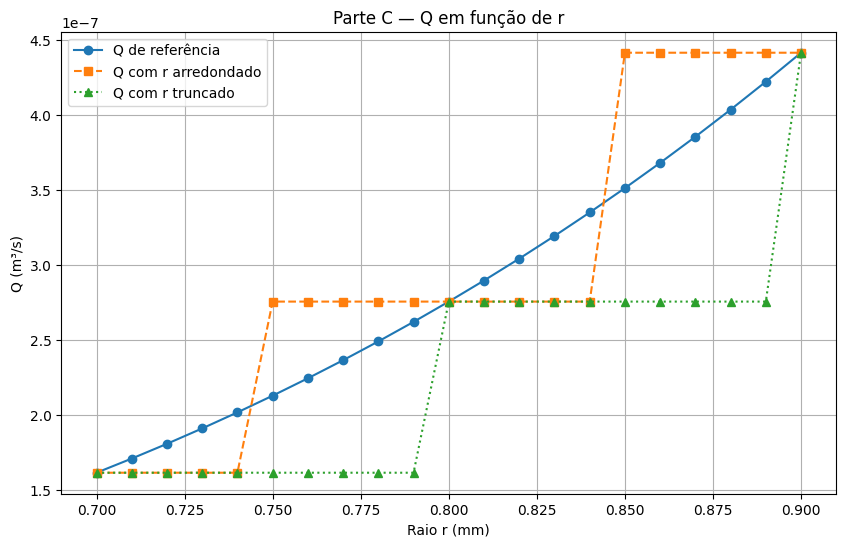

In [13]:
# 1. Q em função de r

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Q_referencia, marker="o", label="Q de referência")
plt.plot(raios_mm, Q_arred, marker="s", linestyle="--", label="Q com r arredondado")
plt.plot(raios_mm, Q_trunc, marker="^", linestyle=":", label="Q com r truncado")
plt.xlabel("Raio r (mm)")
plt.ylabel("Q (m³/s)")
plt.title("Parte C — Q em função de r")
plt.grid(True)
plt.legend()
plt.show()

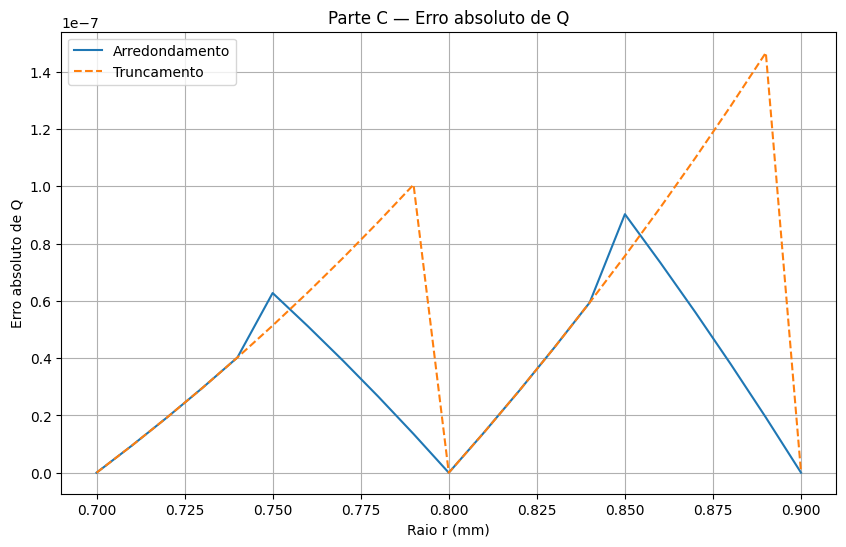

In [14]:
# 2. Erro absoluto de Q em função de r

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Ea_arred, label="Arredondamento")
plt.plot(raios_mm, Ea_trunc, linestyle="--", label="Truncamento")
plt.xlabel("Raio r (mm)")
plt.ylabel("Erro absoluto de Q")
plt.title("Parte C — Erro absoluto de Q")
plt.grid(True)
plt.legend()
plt.show()

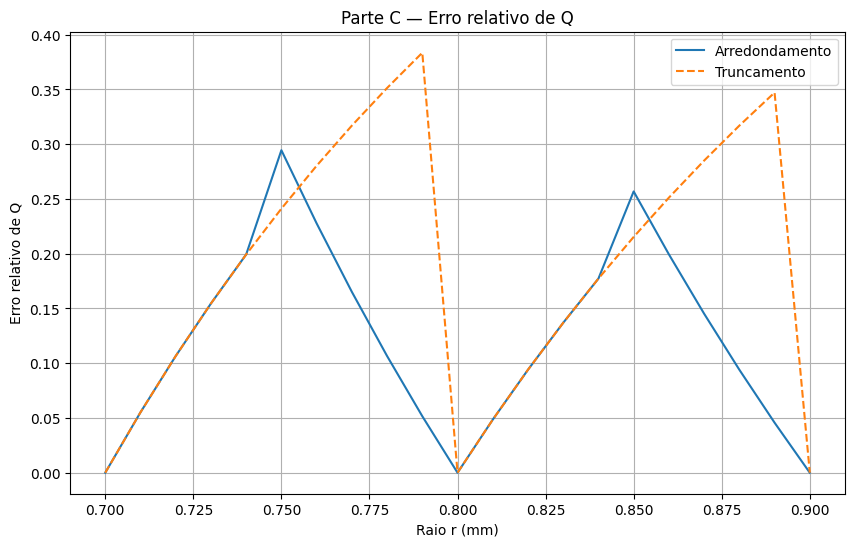

In [15]:
# 3. Erro relativo de Q em função de r

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Er_arred, label="Arredondamento")
plt.plot(raios_mm, Er_trunc, linestyle="--", label="Truncamento")
plt.xlabel("Raio r (mm)")
plt.ylabel("Erro relativo de Q")
plt.title("Parte C — Erro relativo de Q")
plt.grid(True)
plt.legend()
plt.show()

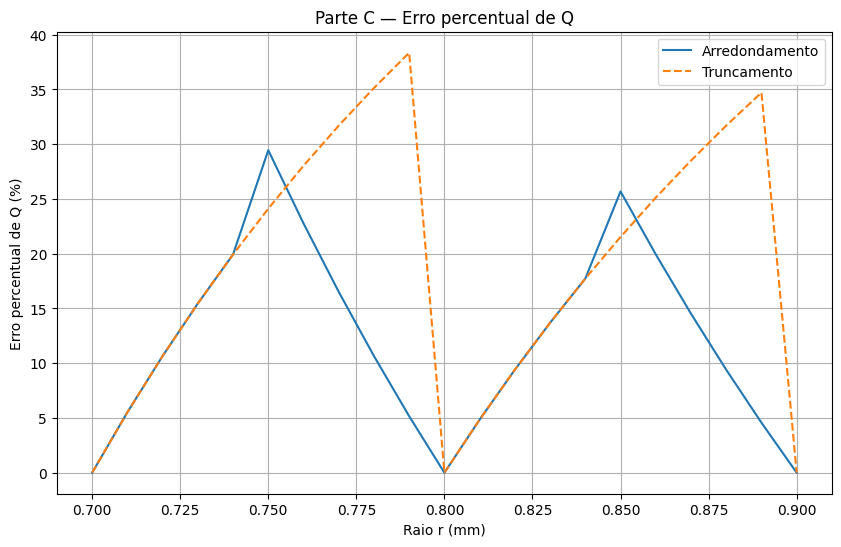

In [16]:
# 4. Erro percentual de Q em função de r

plt.figure(figsize=(10, 6))
plt.plot(raios_mm, Ep_arred, label="Arredondamento")
plt.plot(raios_mm, Ep_trunc, linestyle="--", label="Truncamento")
plt.xlabel("Raio r (mm)")
plt.ylabel("Erro percentual de Q (%)")
plt.title("Parte C — Erro percentual de Q")
plt.grid(True)
plt.legend()
plt.show()

### Explicação

A vazão depende do raio elevado à quarta potência:

Q ∝ r⁴

Portanto, uma pequena variação relativa no raio é amplificada na vazão. Para pequenas variações,
a sensibilidade relativa pode ser aproximada por:

ΔQ/Q ≈ 4 Δr/r.

O fator 4 vem diretamente do expoente do raio na equação de Hagen–Poiseuille.

---


# Parte D — Escoamento em um Nanocateter


## Parte D — Escoamento em um nanocateter

Dados do arquivo:
- r = 50 nm
- L = 10 µm
- μ = 3,5 × 10⁻³ Pa·s
- Δp = 5000 Pa

Será utilizada novamente a equação de Hagen–Poiseuille.

In [17]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def vazao(r, mu, delta_p, L):
    return math.pi * r**4 * delta_p / (8 * mu * L)

r = 50e-9
L = 10e-6
mu = 3.5e-3
delta_p = 5000.0

Q_ref = vazao(r, mu, delta_p, L)

print(f"Q(r = 50 nm) = {Q_ref:.12e} m³/s")

Q(r = 50 nm) = 3.506241800881e-19 m³/s


### D.1 — Erro geométrico

In [18]:
delta_r_nm = np.round(np.arange(0.1, 5.0 + 0.001, 0.1), 1)

r_minus = (50 - delta_r_nm) * 1e-9
r_plus = (50 + delta_r_nm) * 1e-9

Q_minus = np.array([
    vazao(rr, mu, delta_p, L)
    for rr in r_minus
])

Q_plus = np.array([
    vazao(rr, mu, delta_p, L)
    for rr in r_plus
])

Ea_minus = np.abs(Q_minus - Q_ref)
Ea_plus = np.abs(Q_plus - Q_ref)

Ea_max = np.maximum(Ea_minus, Ea_plus)

Er_minus = Ea_minus / abs(Q_ref)
Er_plus = Ea_plus / abs(Q_ref)

Er_max = np.maximum(Er_minus, Er_plus)
Epercent_max = 100 * Er_max

aproximacao_linear = 4 * delta_r_nm / 50

tabela_D1 = pd.DataFrame({
    "Δr (nm)": delta_r_nm,
    "r− (nm)": 50 - delta_r_nm,
    "r+ (nm)": 50 + delta_r_nm,
    "Q(r−)": Q_minus,
    "Q(r)": Q_ref,
    "Q(r+)": Q_plus,
    "Ea máximo": Ea_max,
    "Er máximo": Er_max,
    "E% máximo": Epercent_max,
    "4Δr/r": aproximacao_linear
})

tabela_D1

,Δr (nm),r− (nm),r+ (nm),Q(r−),Q(r),Q(r+),Ea máximo,Er máximo,E% máximo,4Δr/r
0,0.1,49.9,50.1,3.478276e-19,3.506242e-19,3.534376e-19,2.813420e-21,0.008024,0.802403,0.008
1,0.2,49.8,50.2,3.450478e-19,3.506242e-19,3.562679e-19,5.643737e-21,0.016096,1.609626,0.016
2,0.3,49.7,50.3,3.422846e-19,3.506242e-19,3.591152e-19,8.491019e-21,0.024217,2.421687,0.024
3,0.4,49.6,50.4,3.395381e-19,3.506242e-19,3.619795e-19,1.135533e-20,0.032386,3.238605,0.032
4,0.5,49.5,50.5,3.368082e-19,3.506242e-19,3.648609e-19,1.423675e-20,0.040604,4.060401,0.040
5,0.6,49.4,50.6,3.340947e-19,3.506242e-19,3.677595e-19,1.713533e-20,0.048871,4.887093,0.048
6,0.7,49.3,50.7,3.313977e-19,3.506242e-19,3.706753e-19,2.005115e-20,0.057187,5.718701,0.056
7,0.8,49.2,50.8,3.287171e-19,3.506242e-19,3.736085e-19,2.298427e-20,0.065552,6.555245,0.064
8,0.9,49.1,50.9,3.260527e-19,3.506242e-19,3.765590e-19,2.593477e-20,0.073967,7.396743,0.072
9,1.0,49.0,51.0,3.234046e-19,3.506242e-19,3.795269e-19,2.890271e-20,0.082432,8.243216,0.080


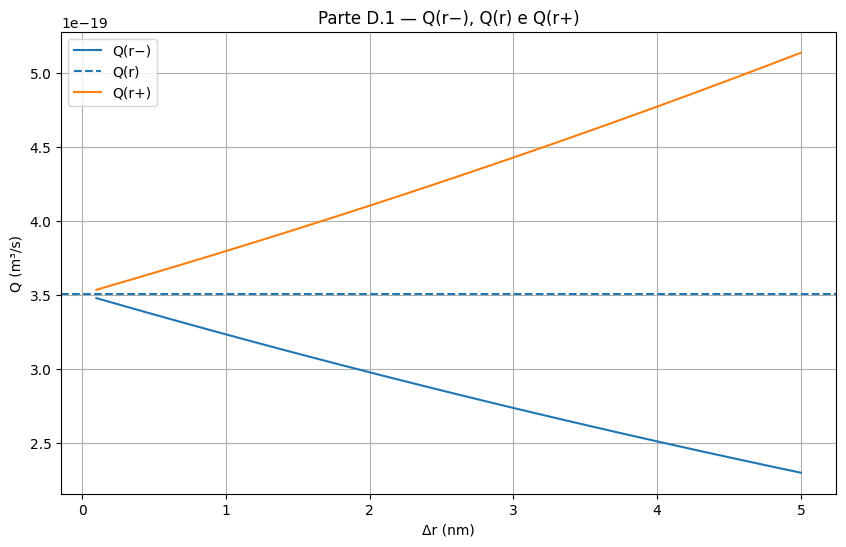

In [19]:
# 1. Q(r−), Q(r) e Q(r+)

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, Q_minus, label="Q(r−)")
plt.axhline(Q_ref, linestyle="--", label="Q(r)")
plt.plot(delta_r_nm, Q_plus, label="Q(r+)")
plt.xlabel("Δr (nm)")
plt.ylabel("Q (m³/s)")
plt.title("Parte D.1 — Q(r−), Q(r) e Q(r+)")
plt.grid(True)
plt.legend()
plt.show()

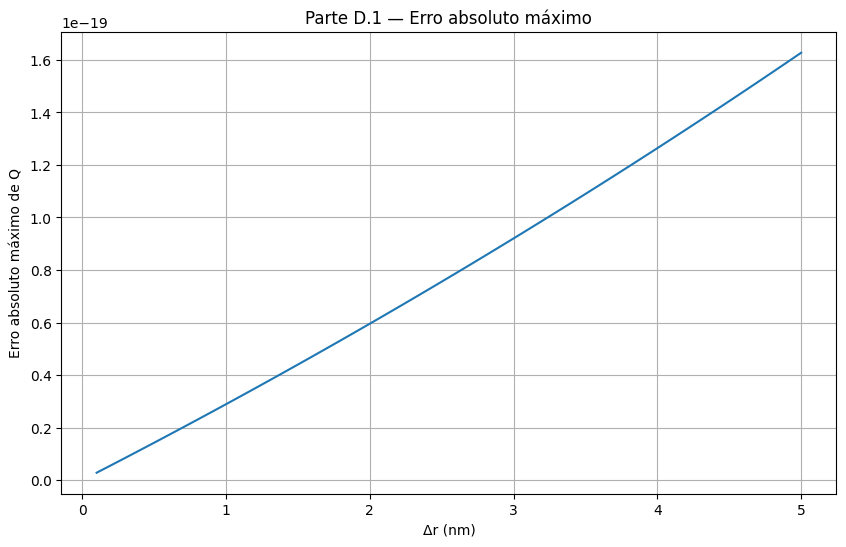

In [20]:
# 2. Erro absoluto máximo

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, Ea_max)
plt.xlabel("Δr (nm)")
plt.ylabel("Erro absoluto máximo de Q")
plt.title("Parte D.1 — Erro absoluto máximo")
plt.grid(True)
plt.show()

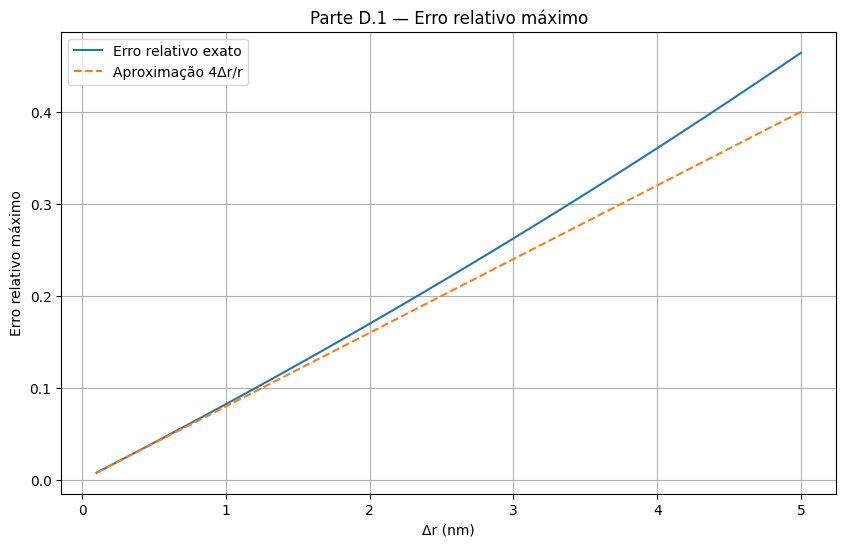

In [21]:
# 3. Erro relativo máximo e aproximação linear

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, Er_max, label="Erro relativo exato")
plt.plot(delta_r_nm, aproximacao_linear, linestyle="--",
         label="Aproximação 4Δr/r")
plt.xlabel("Δr (nm)")
plt.ylabel("Erro relativo máximo")
plt.title("Parte D.1 — Erro relativo máximo")
plt.grid(True)
plt.legend()
plt.show()

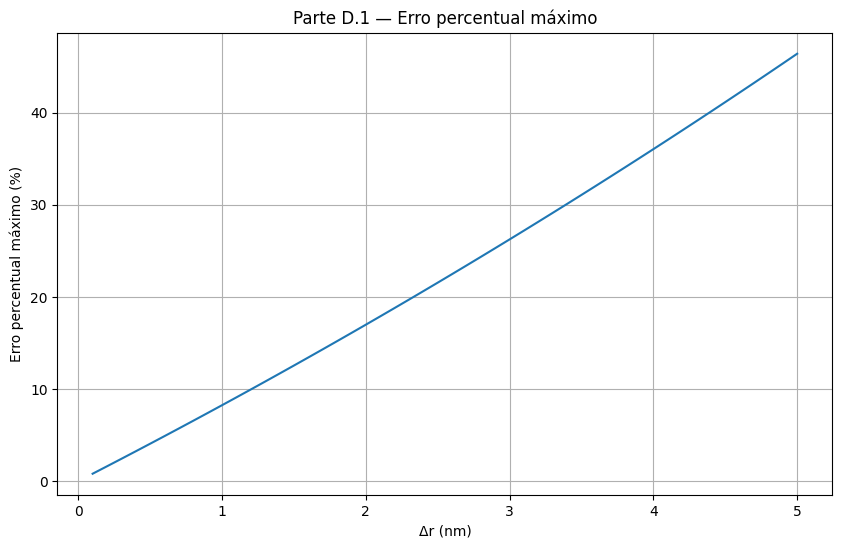

In [22]:
# 4. Erro percentual máximo

plt.figure(figsize=(10, 6))
plt.plot(delta_r_nm, Epercent_max)
plt.xlabel("Δr (nm)")
plt.ylabel("Erro percentual máximo (%)")
plt.title("Parte D.1 — Erro percentual máximo")
plt.grid(True)
plt.show()

### Comparação com a aproximação linear

A aproximação solicitada é:

ΔQ/Q ≈ 4 Δr/r.

Ela é uma aproximação linear e funciona melhor quando Δr/r é pequeno.
Para variações maiores, os termos de ordem superior de (1 ± Δr/r)⁴ passam a ser relevantes.

### D.2 — Precisão computacional

In [23]:
def vazao_numpy(r, dtype):
    rr = dtype(r)
    mm = dtype(mu)
    dd = dtype(delta_p)
    ll = dtype(L)

    return dtype(np.pi) * rr**dtype(4) * dd / (dtype(8) * mm * ll)

Q_float32 = vazao_numpy(r, np.float32)
Q_float64 = vazao_numpy(r, np.float64)

r4_float32 = np.float32(r)**np.float32(4)
r4_float64 = np.float64(r)**np.float64(4)

eps32 = np.finfo(np.float32).eps
eps64 = np.finfo(np.float64).eps

diferenca_absoluta = abs(float(Q_float32) - float(Q_float64))
diferenca_relativa = diferenca_absoluta / abs(float(Q_float64))

tabela_D2 = pd.DataFrame({
    "Precisão": ["float32", "float64"],
    "r⁴": [float(r4_float32), float(r4_float64)],
    "Q": [float(Q_float32), float(Q_float64)],
    "eps": [eps32, eps64]
})

print("Diferença absoluta entre Q32 e Q64 =", diferenca_absoluta)
print("Diferença relativa entre Q32 e Q64 =", diferenca_relativa)

tabela_D2

Diferença absoluta entre Q32 e Q64 = 5.228627689184328e-26
Diferença relativa entre Q32 e Q64 = 1.4912342006389455e-07


,Precisão,r⁴,Q,eps
0,float32,6.250000e-30,3.506242e-19,1.192093e-07
1,float64,6.250000e-30,3.506242e-19,2.220446e-16


In [24]:
# Comparação das expressões δ1 e δ2 para valores progressivamente menores.

razoes = np.array([
    1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7,
    1e-8, 1e-10, 1e-12, 1e-14, 1e-15, 1e-16
])

delta1 = []
delta2 = []

for razao in razoes:
    r_variado = r * (1 + razao)

    Q1 = vazao_numpy(r_variado, np.float64)
    Q0 = vazao_numpy(r, np.float64)

    d1 = (Q1 - Q0) / Q0
    d2 = (1 + razao)**4 - 1

    delta1.append(float(d1))
    delta2.append(float(d2))

tabela_cancelamento = pd.DataFrame({
    "Δr/r": razoes,
    "δ1 — cálculo direto": delta1,
    "δ2 — expressão exata": delta2
})

tabela_cancelamento

,Δr/r,δ1 — cálculo direto,δ2 — expressão exata
0,1.000000e-01,4.641000e-01,4.641000e-01
1,1.000000e-02,4.060401e-02,4.060401e-02
2,1.000000e-03,4.006004e-03,4.006004e-03
3,1.000000e-04,4.000600e-04,4.000600e-04
4,1.000000e-05,4.000060e-05,4.000060e-05
5,1.000000e-06,4.000006e-06,4.000006e-06
6,1.000000e-07,4.000001e-07,4.000001e-07
7,1.000000e-08,4.000000e-08,4.000000e-08
8,1.000000e-10,4.000000e-10,4.000000e-10
9,1.000000e-12,4.000039e-12,4.000356e-12


**Conclusão sobre cancelamento:** quando Δr/r fica muito pequeno, Q(r + Δr) e Q(r)
ficam extremamente próximos. A subtração entre números quase iguais pode eliminar algarismos
significativos, causando perda de significância na expressão δ1. A expressão δ2 evita essa
subtração direta entre duas vazões.

### D.3 — Fenômeno físico

Ao reduzir a escala do canal, a razão superfície/volume aumenta. Dessa forma, os efeitos viscosos
e de parede tornam-se mais importantes. No modelo utilizado, a vazão depende de r⁴, portanto
pequenas alterações geométricas no raio podem produzir alterações intensas na vazão.

Precisão aritmética e validade do modelo são conceitos diferentes: um resultado pode ter muitas
casas decimais e alta precisão numérica sem que isso garanta que o modelo físico seja adequado
para descrever completamente o sistema.

---


# Parte E — Síntese Visual


## Parte E — Síntese visual

O arquivo da atividade solicita um quadro único de resultados em PNG, com no mínimo
1600 × 1000 pixels, contendo:
- cartões com principais valores de pressão e vazão;
- comparação entre truncamento e arredondamento;
- os três tipos de erro;
- sensibilidade de Q ao raio;
- comparação float32 e float64;
- conclusão curta sobre o nanocateter.

Este notebook recalcula os principais resultados necessários e gera o quadro.

In [25]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Funções
def truncar(x, n):
    fator = 10**n
    return math.trunc(x*fator)/fator

def arredondar(x, n):
    fator = 10**n
    return math.floor(x*fator + 0.5)/fator

def vazao(r, mu, dp, L):
    return math.pi*r**4*dp/(8*mu*L)

def erros(x, xa):
    Ea = abs(x-xa)
    Er = Ea/abs(x)
    return Ea, Er, 100*Er

# Parte B
pressao = np.array([
    121.7,120.4,122.1,119.8,121.2,
    120.9,122.4,121.0,120.2,121.5
])

media_ref = pressao.mean()
pressao_arred = np.floor(pressao+0.5)
pressao_trunc = np.trunc(pressao)

Ea_arred_B, Er_arred_B, Ep_arred_B = erros(
    media_ref, pressao_arred.mean()
)
Ea_trunc_B, Er_trunc_B, Ep_trunc_B = erros(
    media_ref, pressao_trunc.mean()
)

# Parte C
rC = 0.80e-3
LC = 0.20
muC = 3.5e-3
dpC = 1200

QC = vazao(rC,muC,dpC,LC)

# Parte D
rD = 50e-9
LD = 10e-6
muD = 3.5e-3
dpD = 5000

QD = vazao(rD,muD,dpD,LD)

# float32 e float64
def vazao_np(r, dtype):
    rr=dtype(r)
    mm=dtype(muD)
    dd=dtype(dpD)
    ll=dtype(LD)
    return dtype(np.pi)*rr**dtype(4)*dd/(dtype(8)*mm*ll)

Q32 = vazao_np(rD,np.float32)
Q64 = vazao_np(rD,np.float64)

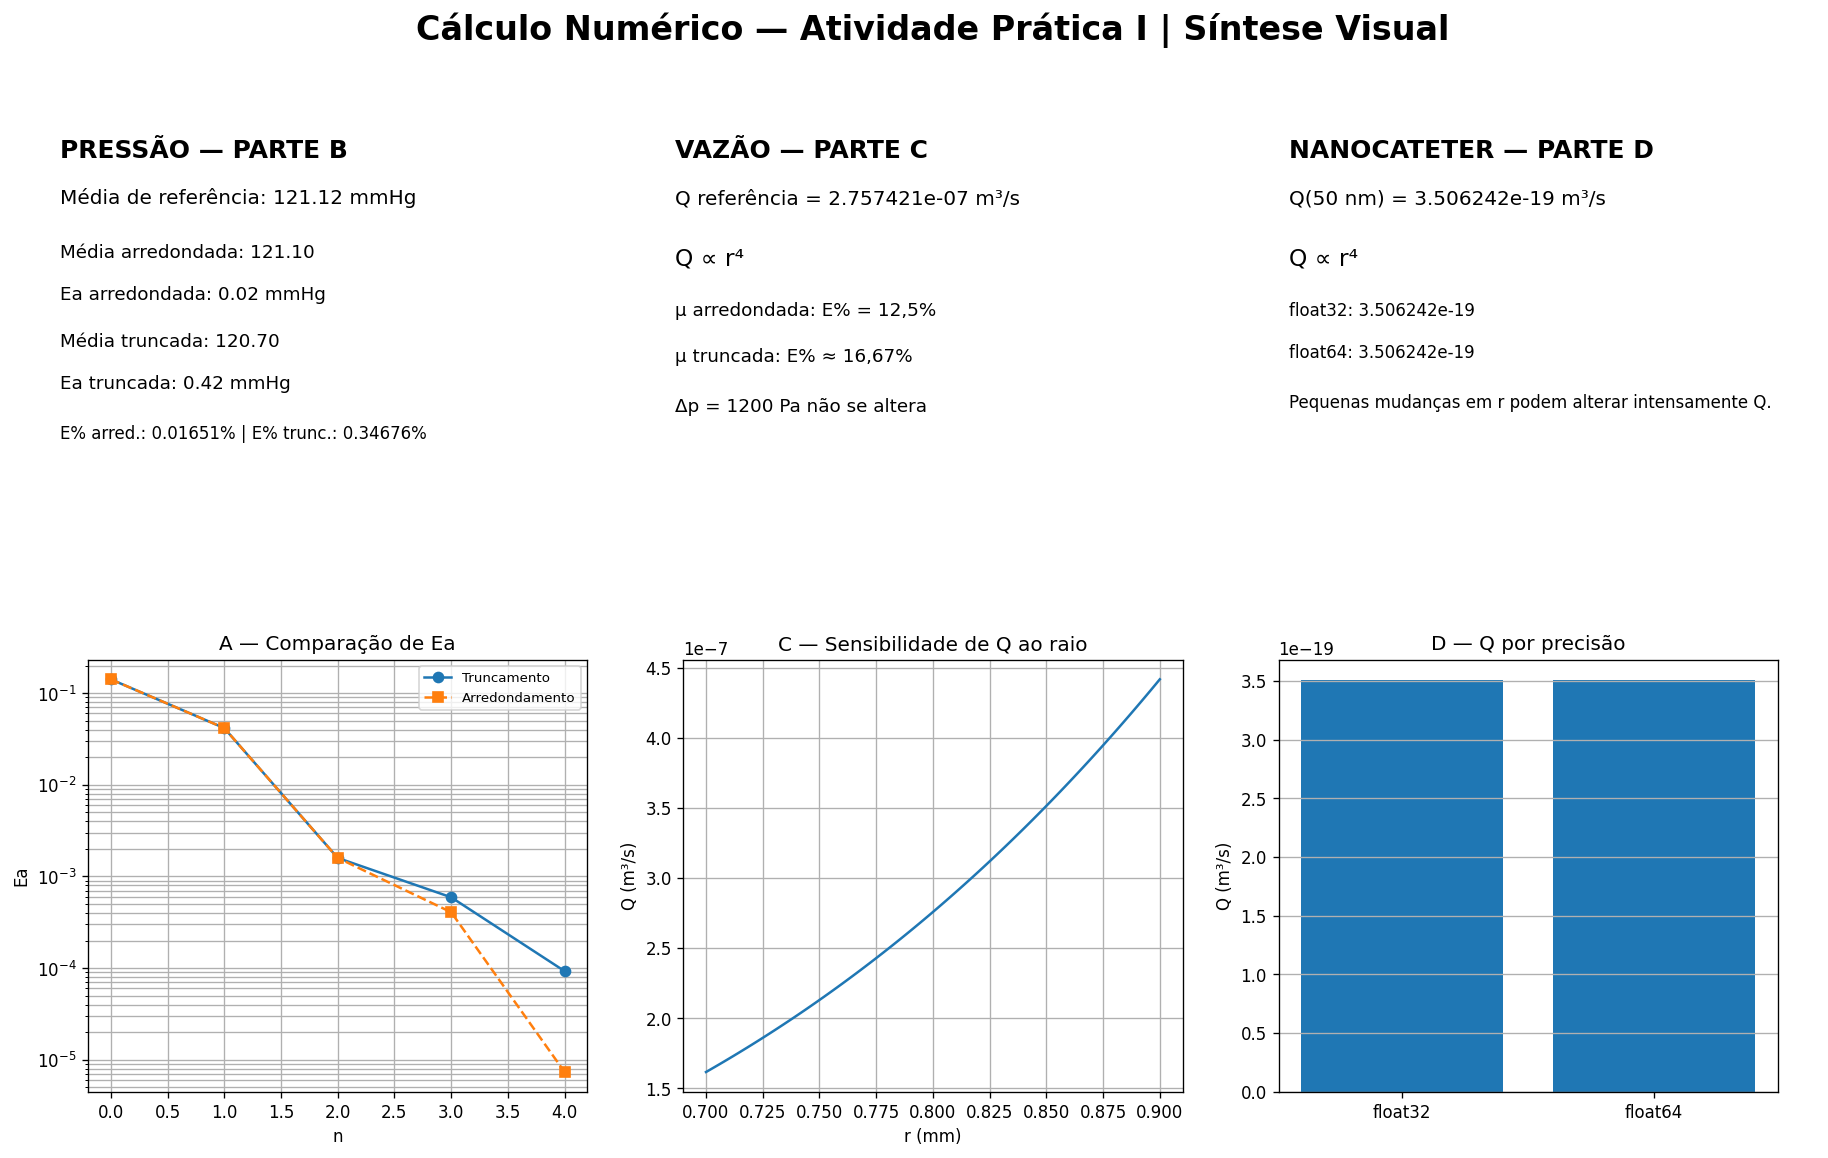

Arquivo gerado: quadro_unico_resultados.png


In [26]:
    # Sensibilidade ao raio para o painel

    raios = np.linspace(0.70,0.90,101)
    Q_raios = np.array([
        vazao(rr*1e-3,muC,dpC,LC)
        for rr in raios
    ])

    # Criação do quadro com mais de 1600 x 1000 pixels.
    fig = plt.figure(figsize=(16,10), dpi=120)
    fig.suptitle(
        "Cálculo Numérico — Atividade Prática I | Síntese Visual",
        fontsize=20, fontweight="bold"
    )

    # Cartão B
    ax1 = fig.add_axes([0.04,0.57,0.28,0.32])
    ax1.axis("off")
    ax1.text(0.02,0.95,"PRESSÃO — PARTE B",
             fontsize=15,fontweight="bold",va="top")
    ax1.text(0.02,0.78,f"Média de referência: {media_ref:.2f} mmHg",
             fontsize=12)
    ax1.text(0.02,0.64,f"Média arredondada: {pressao_arred.mean():.2f}",
             fontsize=11)
    ax1.text(0.02,0.53,f"Ea arredondada: {Ea_arred_B:.2f} mmHg",
             fontsize=11)
    ax1.text(0.02,0.41,f"Média truncada: {pressao_trunc.mean():.2f}",
             fontsize=11)
    ax1.text(0.02,0.30,f"Ea truncada: {Ea_trunc_B:.2f} mmHg",
             fontsize=11)
    ax1.text(0.02,0.17,f"E% arred.: {Ep_arred_B:.5f}% | E% trunc.: {Ep_trunc_B:.5f}%",
             fontsize=10)

    # Cartão C
    ax2 = fig.add_axes([0.36,0.57,0.28,0.32])
    ax2.axis("off")
    ax2.text(0.02,0.95,"VAZÃO — PARTE C",
             fontsize=15,fontweight="bold",va="top")
    ax2.text(0.02,0.78,f"Q referência = {QC:.6e} m³/s",
             fontsize=12)
    ax2.text(0.02,0.62,"Q ∝ r⁴",fontsize=14)
    ax2.text(0.02,0.49,"μ arredondada: E% = 12,5%",
             fontsize=11)
    ax2.text(0.02,0.37,"μ truncada: E% ≈ 16,67%",
             fontsize=11)
    ax2.text(0.02,0.24,"Δp = 1200 Pa não se altera",
             fontsize=11)

    # Cartão D
    ax3 = fig.add_axes([0.68,0.57,0.28,0.32])
    ax3.axis("off")
    ax3.text(0.02,0.95,"NANOCATETER — PARTE D",
             fontsize=15,fontweight="bold",va="top")
    ax3.text(0.02,0.78,f"Q(50 nm) = {QD:.6e} m³/s",
             fontsize=12)
    ax3.text(0.02,0.62,"Q ∝ r⁴",
             fontsize=14)
    ax3.text(0.02,0.49,f"float32: {float(Q32):.6e}",
             fontsize=10)
    ax3.text(0.02,0.38,f"float64: {float(Q64):.6e}",
             fontsize=10)
    ax3.text(0.02,0.25, "Pequenas mudanças em r podem alterar intensamente Q.", fontsize=10)

    # Comparação de erros A
    ax4 = fig.add_axes([0.06,0.08,0.26,0.36])
    x1=3.14159265
    n=np.arange(5)
    ea_t=[abs(x1-truncar(x1,int(i))) for i in n]
    ea_a=[abs(x1-arredondar(x1,int(i))) for i in n]
    ax4.semilogy(n,ea_t,marker="o",label="Truncamento")
    ax4.semilogy(n,ea_a,marker="s",linestyle="--",label="Arredondamento")
    ax4.set_title("A — Comparação de Ea")
    ax4.set_xlabel("n")
    ax4.set_ylabel("Ea")
    ax4.grid(True,which="both")
    ax4.legend(fontsize=8)

    # Sensibilidade C
    ax5 = fig.add_axes([0.37,0.08,0.26,0.36])
    ax5.plot(raios,Q_raios)
    ax5.set_title("C — Sensibilidade de Q ao raio")
    ax5.set_xlabel("r (mm)")
    ax5.set_ylabel("Q (m³/s)")
    ax5.grid(True)

    # float32 x float64
    ax6 = fig.add_axes([0.68,0.08,0.26,0.36])
    ax6.bar(["float32","float64"],[float(Q32),float(Q64)])
    ax6.set_title("D — Q por precisão")
    ax6.set_ylabel("Q (m³/s)")
    ax6.ticklabel_format(axis="y",style="sci",scilimits=(0,0))
    ax6.grid(axis="y")

    caminho = "quadro_unico_resultados.png"
    fig.savefig(caminho,dpi=160,bbox_inches="tight")
    plt.show()

    print("Arquivo gerado:", caminho)

### Conclusão curta

A atividade evidencia que a maneira como os valores são representados numericamente interfere nos erros dos cálculos.

No cálculo da vazão, esse efeito se torna mais significativo devido à dependência da quarta potência do raio.

No caso do nanocateter, mesmo pequenas mudanças no raio podem causar variações consideráveis na vazão.

Além disso, é importante diferenciar a precisão dos cálculos computacionais da capacidade do modelo matemático de representar adequadamente o fenômeno físico.

---


# Seção 8 — GIF Demonstrativo do Nanocateter


## Seção 8 — GIF demonstrativo do nanocateter

O arquivo da atividade solicita um GIF com 30 a 60 quadros.
O raio deve variar de 45 a 55 nm e cada quadro deve apresentar:
- seção transversal do canal;
- raio atual e vazão calculada;
- erro percentual em relação a r = 50 nm;
- curva Q × r sendo construída progressivamente.

Este notebook gera 45 quadros.

In [27]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def vazao(r, mu, delta_p, L):
    return math.pi*r**4*delta_p/(8*mu*L)

r_ref = 50e-9
L = 10e-6
mu = 3.5e-3
delta_p = 5000.0

Q_ref = vazao(r_ref,mu,delta_p,L)

raios_nm = np.linspace(45,55,45)

Qs = np.array([
    vazao(rr*1e-9,mu,delta_p,L)
    for rr in raios_nm
])

erros_percentuais = (
    np.abs(Qs-Q_ref)/abs(Q_ref)*100
)

print("Q de referência =", Q_ref)
print("Número de quadros =", len(raios_nm))

Q de referência = 3.506241800881465e-19
Número de quadros = 45


In [28]:
fig = plt.figure(figsize=(10,5.5))

ax_canal = fig.add_axes([0.06,0.12,0.36,0.78])
ax_curva = fig.add_axes([0.50,0.15,0.45,0.68])

def atualizar(i):
    ax_canal.clear()
    ax_curva.clear()

    raio = raios_nm[i]
    Q_atual = Qs[i]
    erro = erros_percentuais[i]

    # Seção transversal
    theta = np.linspace(0,2*np.pi,300)

    ax_canal.fill(
        raio*np.cos(theta),
        raio*np.sin(theta),
        alpha=0.25
    )

    ax_canal.set_aspect("equal")
    ax_canal.set_xlim(-57,57)
    ax_canal.set_ylim(-57,57)

    ax_canal.set_xlabel("nm")
    ax_canal.set_ylabel("nm")
    ax_canal.set_title("Seção transversal do canal")

    ax_canal.text(
        0.02,0.95,
        f"r = {raio:.2f} nm\n"
        f"Q = {Q_atual:.3e} m³/s\n"
        f"Erro = {erro:.3f}%",
        transform=ax_canal.transAxes,
        va="top",
        fontsize=11
    )

    ax_canal.grid(True)

    # Curva sendo construída
    ax_curva.plot(
        raios_nm[:i+1],
        Qs[:i+1],
        marker="o"
    )

    ax_curva.axvline(
        50,linestyle="--",
        label="r = 50 nm"
    )

    ax_curva.axhline(
        Q_ref,linestyle=":",
        label="Q(50 nm)"
    )

    ax_curva.set_xlim(45,55)
    ax_curva.set_ylim(
        Qs.min()*0.95,
        Qs.max()*1.05
    )

    ax_curva.set_xlabel("Raio r (nm)")
    ax_curva.set_ylabel("Q (m³/s)")
    ax_curva.set_title("Construção progressiva de Q × r")
    ax_curva.grid(True)
    ax_curva.legend()

    fig.suptitle(
        f"Nanocateter — quadro {i+1}/45",
        fontsize=14
    )

animacao = FuncAnimation(
    fig,
    atualizar,
    frames=45,
    interval=120
)

caminho = "nanocateter_45_quadros.gif"

animacao.save(
    caminho,
    writer=PillowWriter(fps=8)
)

plt.close(fig)

print("GIF gerado:", caminho)

GIF gerado: nanocateter_45_quadros.gif
